# Tutorial: Graph perturbations with `CellinaGAT`

`CellinaGAT` is a dual-encoder VAE that separates intrinsic cell state ($z$) from spatial context ($s$) using GATv2 attention over each cell's local subgraph. The two latent spaces enable **tissue-graph counterfactuals**: hold a cell's identity fixed and ask what it would express under a different neighbourhood.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc
import torch
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping
from scipy.stats import pearsonr

from cellina import CellinaGCN, make_perturbed_expression
from cellina._spatial_utils import spatial_neighbors

In [3]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 1. Data preprocessing

In [4]:
adata = sc.read(
    f"./data/crc_232.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/232.h5ad?download=1"
)
adata.obs_names_make_unique()

In [5]:
label_to_coarse = {
    "epi1": "Epithelial", "epi2": "Epithelial", "epi3": "Epithelial", "epi4": "Epithelial",
    "fib1": "Fibroblast", "fib2": "Fibroblast",
    "EC": "Endothelial", "SMC": "Smooth_muscle",
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell", "PC_IgG": "Plasma_cell", "PC_IgM": "Plasma_cell",
    "TC": "T_cell",
    "mye1": "Myeloid", "mye2": "Myeloid",
    "mast": "Mast_cell",
}
adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)

In [6]:
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = None

adata = adata[~adata.obs[domains_key].isna()]
adata = adata[~adata.obs[labels_key].isna()]
sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


### Data splits

Hold out Myeloid cells in the cancer (CRC) region for out-of-distribution evaluation.

In [7]:
holdout_ct = 'Myeloid'
is_tumor_region = adata.obs[domains_key].str.contains("CRC", regex=True)
is_holdout_ct = adata.obs[labels_key] == holdout_ct

test_mask = is_tumor_region & is_holdout_ct
test_idx = np.where(test_mask)[0]

all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

train_idx, val_idx = train_test_split(trainval_idx, test_size=0.1, random_state=0, shuffle=True)
print("Train:", len(train_idx), "| Val:", len(val_idx), "| Test:", len(test_idx))

Train: 96258 | Val: 10696 | Test: 5035


### Spatial graph

`CellinaGCN` operates directly on the spatial graph — no pre-aggregation of neighbour features is needed. We build the adjacency with test nodes masked out to avoid data leakage, and store the original adjacency for counterfactual inference.

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

max_neighbors = 20
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.obsp['spatial_connectivities_orig'] = spatial_neighbors(
    adata, bandwidth=100 / 0.12028, max_neighbours=max_neighbors,
    standardize=False, inplace=False
)
spatial_neighbors(
    adata, bandwidth=100 / 0.12028, max_neighbours=max_neighbors,
    standardize=False, test_indices=test_idx
)

adata.X = adata.layers['counts'].copy()  # reset to raw counts for CellinaGCN

## 2. Training

In [9]:
train_args = {
    "max_epochs": 100,
    "batch_size": 2048,
    "check_val_every_n_epoch": 1,
    "early_stopping": True,
    "enable_checkpointing": True,
    "early_stopping_patience": 10,
    "early_stopping_monitor": "vae_loss_validation",
    "devices": [0],
    "datasplitter_kwargs": {"external_indexing": [train_idx, val_idx, test_idx]},
    "callbacks": [
        SaveCheckpoint(
            monitor='vae_loss_validation',
            dirpath=f"scvi_log/cellina_gcn/",
            load_best_on_end=True),
        EarlyStopping(
            monitor="vae_loss_validation",
            patience=10,
            mode="min"),
    ],
}

plan_kwargs = {
    "lr": 1e-3,
    "normalize_losses": True,
}

In [10]:
cellina_gcn_args = {
    "n_latent": 64,
    "use_observed_lib_size": True,
    "condition_on_intrinsic": False,
    "classifier_lambda": 1.0,
    "discriminator_lambda": 1.0,
    "link_prediction_weight": 1.0,
    "gene_likelihood": "nb",
    "n_layers": 2,
    "num_neighbors": [20, 20],
    "convolution_type": "gat",
}

In [11]:
CellinaGCN.setup_anndata(
    adata,
    batch_key=batch_key,
    labels_key=labels_key,
    domains_key=domains_key,
    spatial_connectivities_key='spatial_connectivities',
    layer='counts'
)
model = CellinaGCN(adata, **cellina_gcn_args)

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [12]:
model.train(**train_args, plan_kwargs=plan_kwargs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/100 [00:00<?, ?it/s]

INFO     File                                                                                                      
         /data/ddimitrov/repos/cellina/docs/scvi_log/cellina_gcn/epoch=6-step=576-vae_loss_validation=327.782806396
         4844/model.pt already downloaded                                                                          
Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 327.783. Signaling Trainer to stop.


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

## 3. Qualitative Analysis

If disentanglement worked, $z$ clusters by cell type (adversary removed domain signal) and $s$ organises by tissue region.

In [13]:
checkpoint_name = os.listdir("scvi_log/cellina_gcn/")[0]
model = CellinaGCN.load(
    f"scvi_log/cellina_gcn/{checkpoint_name}",
    adata=adata,
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File scvi_log/cellina_gcn/epoch=6-step=576-vae_loss_validation=327.7828063964844/model.pt already         
         downloaded                                                                                                


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

INFO     cellina: The CellinaGCN model has been initialized with adversarial domain forgetting with edge prediction


In [14]:
adata.obsm['cellina_basal'] = model.get_latent_representation(latent_key='z', batch_size=2048)
adata.obsm['cellina_spatial'] = model.get_latent_representation(latent_key='s', batch_size=2048)

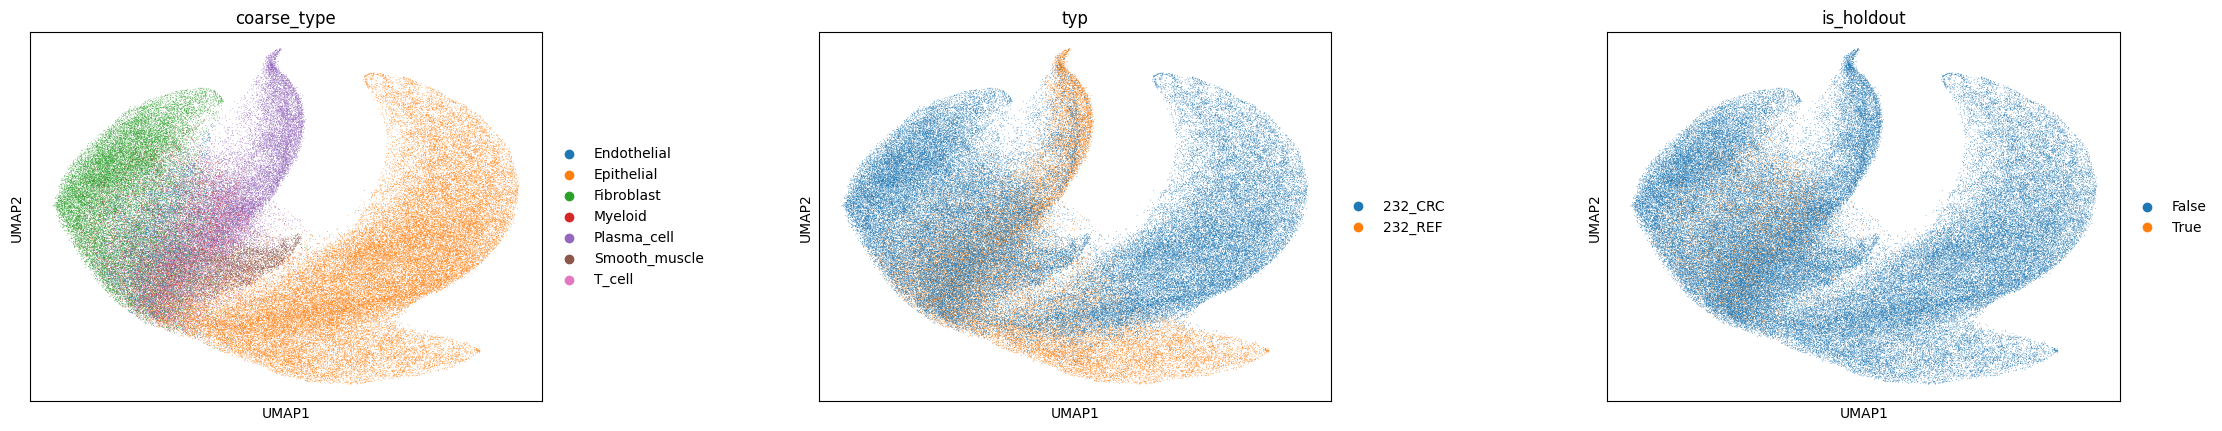

In [15]:
sc.pp.neighbors(adata, use_rep='cellina_basal')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key, 'is_holdout'], wspace=0.4)

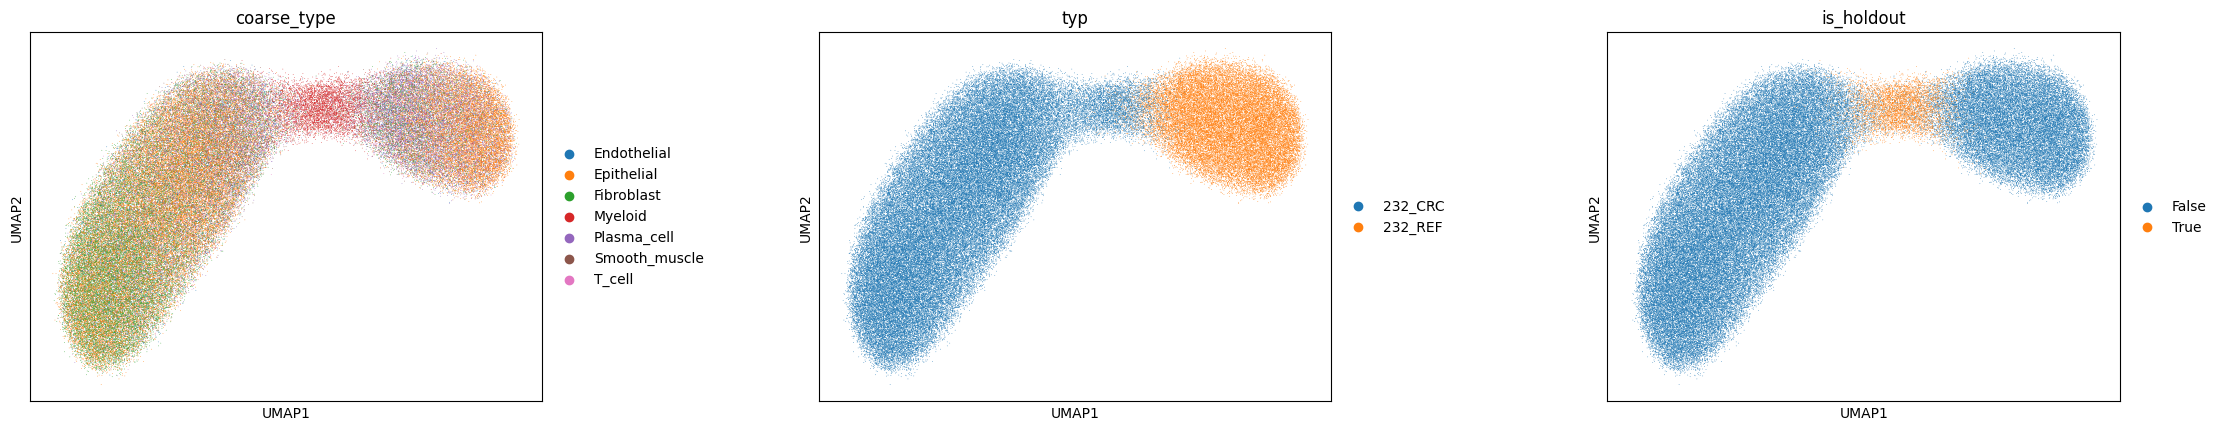

In [16]:
sc.pp.neighbors(adata, use_rep='cellina_spatial')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key, 'is_holdout'], wspace=0.4)

## 4. Counterfactuals

In [17]:
is_control_region = adata.obs[domains_key].str.contains('REF')
mask_control = is_control_region & is_holdout_ct
idx_control = np.where(mask_control.values)[0]

mask_target = is_tumor_region & is_holdout_ct
idx_target = np.where(mask_target.values)[0]

In [18]:
def _normalize_counts(x, eps=1e-8, scale=1e4):
    return x / (x.sum(axis=1, keepdims=True) + eps) * scale

def safe_log2_fold_change(a, b, eps=1e-6):
    return np.log2((np.asarray(a) + eps) / (np.asarray(b) + eps))

def get_lfc(control, target, counterfactual, normalize_counts=True, n_deg=200):
    if normalize_counts:
        control = _normalize_counts(control)
        target = _normalize_counts(target)
        counterfactual = _normalize_counts(counterfactual)
    mean_control = np.nanmean(control, axis=0)
    mean_target = np.nanmean(target, axis=0)
    mean_cf = np.nanmean(counterfactual, axis=0)
    gt_vec = safe_log2_fold_change(mean_target, mean_control)
    cf_vec = safe_log2_fold_change(mean_cf, mean_control)
    top_features = np.argsort(-np.abs(gt_vec))[:n_deg]
    return gt_vec, cf_vec, top_features

In [19]:
from adjustText import adjust_text

def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    deg = np.asarray(deg)
    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)
    ax.scatter(true_lfc[non_deg], pred_lfc[non_deg], alpha=0.25, s=8, color="lightgray",
               linewidths=0, rasterized=True)
    up = deg[true_lfc[deg] >= 0]
    down = deg[true_lfc[deg] < 0]
    ax.scatter(true_lfc[up], pred_lfc[up], s=45, color="#d62728",
               edgecolor="white", linewidths=0.5, zorder=3, label="up in cancer")
    ax.scatter(true_lfc[down], pred_lfc[down], s=45, color="#1f77b4",
               edgecolor="white", linewidths=0.5, zorder=3, label="down in cancer")
    texts = [ax.text(true_lfc[i], pred_lfc[i], gene_names[i], fontsize=8) for i in deg]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5))
    lo = float(min(true_lfc.min(), pred_lfc.min()))
    hi = float(max(true_lfc.max(), pred_lfc.max()))
    pad = 0.05 * (hi - lo)
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.6, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_xlabel("Observed logFC  (control → cancer)")
    ax.set_ylabel("Predicted logFC  (counterfactual)")
    ax.set_title(f"{holdout_ct}: observed vs. predicted logFC   (Pearson r = {pearson:.2f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    plt.show()

### 4.1 Edge perturbation

Rewire each control Myeloid's neighbourhood by sampling from the observed neighbours of cancer Myeloids (excluding Myeloids themselves). `CellinaGCN` aggregates over the rewired graph on the fly.

In [20]:
conn = adata.obsp["spatial_connectivities_orig"]
sub_conn = conn[idx_target]
neighbor_indices = np.unique(sub_conn.nonzero()[1])
neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

In [21]:
counterfactual_counts = model.get_counterfactual_expression(
    indices=idx_control,
    neighbour_indices=neighbor_indices,
    n_neighbors_per_seed=20,
    batch_size=2048,
    seed=0,
    library_size=1e4,
)

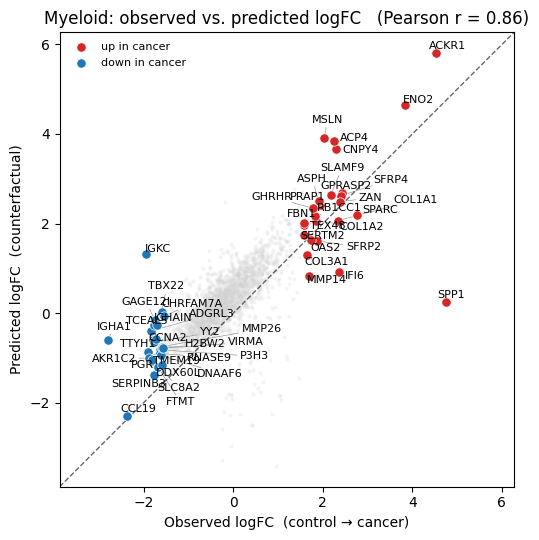

In [22]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target,
                                   counterfactual=counterfactual_counts, n_deg=50)
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])

gene_names = np.array(adata.var_names)
plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)

### 4.2 Node perturbation

Keep graph topology fixed; shift the expression of each neighbour cell by the observed healthy→cancer log-fold change for its cell type (using the global average for the held-out Myeloid population). The GAT aggregates from the perturbed neighbour counts on the fly via `cf_layer`.

In [23]:
import pandas as pd
import scipy.sparse as sp
import decoupler as dc

n_pert_genes = 200
control_domain = '232_REF'
target_domain = '232_CRC'

def get_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key):
    pdata_ct = dc.pp.pseudobulk(
        adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_ct, target_sum=1e4)
    sc.pp.log1p(pdata_ct)
    cell_types_with_both = [
        ct for ct in pdata_ct.obs[labels_key].unique()
        if ((pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == ct)).any()
        and ((pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == ct)).any()
    ]
    _ct_rows = []
    for _ct in cell_types_with_both:
        _crc_ct = pdata_ct[(pdata_ct.obs[domains_key] == holdout_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _ref_ct = pdata_ct[(pdata_ct.obs[domains_key] == control_domain) & (pdata_ct.obs[labels_key] == _ct)].X
        _crc_m = np.asarray(_crc_ct.mean(axis=0)).flatten() if sp.issparse(_crc_ct) else _crc_ct.mean(axis=0).flatten()
        _ref_m = np.asarray(_ref_ct.mean(axis=0)).flatten() if sp.issparse(_ref_ct) else _ref_ct.mean(axis=0).flatten()
        _ct_rows.append(pd.Series(_crc_m - _ref_m, index=pdata_ct.var_names, name=_ct))
    return pd.concat(_ct_rows, axis=1).T

def get_global_perturbation_logfc(adata, control_domain, holdout_domain, labels_key, domains_key, holdout_ct):
    adata_sub = adata[adata.obs[labels_key] != holdout_ct]
    pdata_global = dc.pp.pseudobulk(
        adata=adata_sub, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
    )
    sc.pp.normalize_total(pdata_global, target_sum=1e4)
    sc.pp.log1p(pdata_global)
    _holdout_X = pdata_global[pdata_global.obs[domains_key] == holdout_domain].X
    _control_X = pdata_global[pdata_global.obs[domains_key] == control_domain].X
    _holdout_mean = np.asarray(_holdout_X.mean(axis=0)).flatten() if sp.issparse(_holdout_X) else _holdout_X.mean(axis=0).flatten()
    _control_mean = np.asarray(_control_X.mean(axis=0)).flatten() if sp.issparse(_control_X) else _control_X.mean(axis=0).flatten()
    return pd.Series(_holdout_mean - _control_mean, index=pdata_global.var_names)

In [24]:
domain_logfc_df = get_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key)
global_logfc_series = get_global_perturbation_logfc(adata, control_domain, target_domain, labels_key, domains_key, holdout_ct)
domain_logfc_df.loc[holdout_ct, global_logfc_series.index] = global_logfc_series

logfc_series_dict = {}
for ct in domain_logfc_df.index:
    s = domain_logfc_df.loc[ct]
    top_g = s.abs().nlargest(n_pert_genes).index.tolist()
    logfc_series_dict[ct] = s[top_g]

In [25]:
adata.X = adata.layers['counts'].copy()

make_perturbed_expression(
    adata,
    perturbations=logfc_series_dict,
    groupby=labels_key,
    layer_key='counts_cf',
    base=np.e,
    add_shift=False,
    renormalize=True,
)
pert_expr = model.get_perturbed_expression(
    adata=adata, indices=idx_control, cf_layer='counts_cf',
    batch_size=2048, library_size=1e4,
)

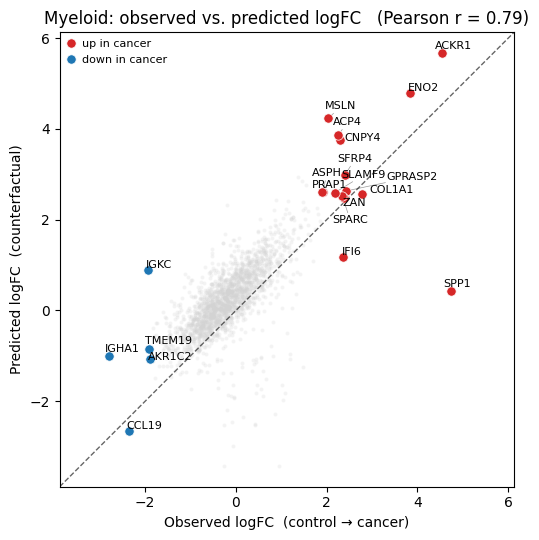

In [26]:
control = np.array(adata.layers['counts'][mask_control.values, :].todense())
target = np.array(adata.layers['counts'][mask_target.values, :].todense())

true_lfc, pred_lfc, deg = get_lfc(control=control, target=target,
                                   counterfactual=pert_expr, n_deg=20)
pearson, _ = pearsonr(true_lfc[deg], pred_lfc[deg])
plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson)